In [1]:
# 运行此单元格（点击左侧 ▶️ 或 Ctrl+Enter）
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

print("✅ 库加载成功！")

✅ 库加载成功！


In [2]:
# 仿真参数（简化版）
fs = 10e6          # 采样率 10 MHz（远低于真实，但够用）
duration = 0.01    # 仿真时长 10 ms
fc = 1.57542e9     # GPS L1 中心频率（实际不用于基带仿真）
f_jam = 1e6        # 干扰频率（相对于基带 1 MHz）
jam_power = 0.5    # 干扰功率（相对于信号）

# 时间向量
t = np.arange(0, duration, 1/fs)

print(f"采样点数: {len(t)}")

采样点数: 100000


In [3]:
# 真实 GNSS 有 C/A 码，但教学可简化为带限白噪声
np.random.seed(42)  # 固定随机种子，结果可复现
gnss_signal = np.random.normal(0, 0.1, len(t))

print("✅ 模拟 GNSS 信号生成（简化为白噪声）")

✅ 模拟 GNSS 信号生成（简化为白噪声）


这里可输入原理，用公式表示

In [4]:
# 窄带干扰：正弦波（最常见干扰类型）
jamming = jam_power * np.sin(2 * np.pi * f_jam * t)

# 受干扰信号
received_signal = gnss_signal + jamming

print("✅ 窄带干扰已叠加！")

✅ 窄带干扰已叠加！


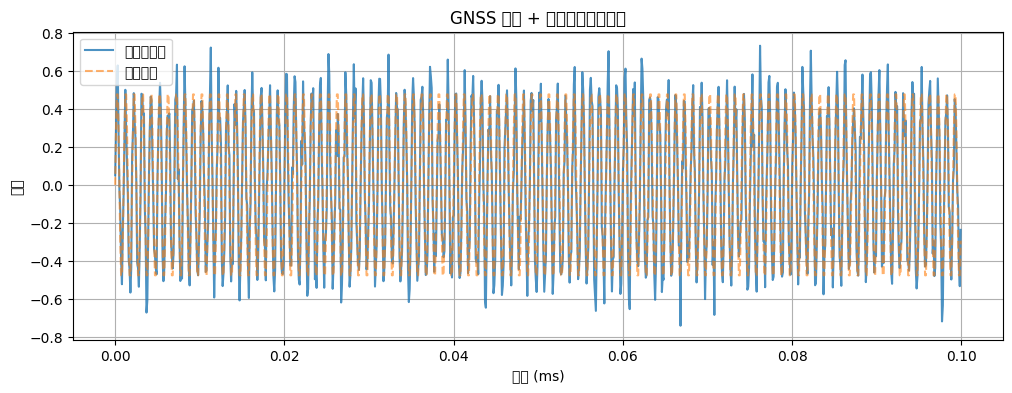

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(t[:1000] * 1000, received_signal[:1000], label='受干扰信号', alpha=0.8)
plt.plot(t[:1000] * 1000, jamming[:1000], '--', label='干扰分量', alpha=0.6)
plt.xlabel('时间 (ms)')
plt.ylabel('幅度')
plt.title('GNSS 信号 + 窄带干扰（时域）')
plt.legend()
plt.grid(True)
plt.show()

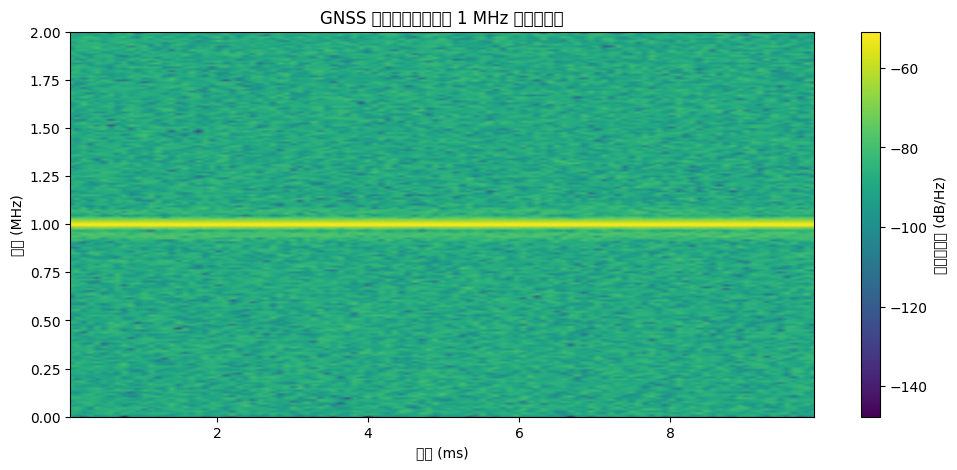

In [8]:
# 计算短时傅里叶变换（STFT）
f, t_stft, Sxx = signal.spectrogram(received_signal, fs=fs, nperseg=1024)

# 绘制频谱图
plt.figure(figsize=(12, 5))
plt.pcolormesh(t_stft * 1000, f / 1e6, 10 * np.log10(Sxx), shading='gouraud')
plt.ylabel('频率 (MHz)')
plt.xlabel('时间 (ms)')
plt.title('GNSS 信号频谱图（可见 1 MHz 处强干扰）')
plt.colorbar(label='功率谱密度 (dB/Hz)')
plt.ylim(0, 2)  # 只看 0～2 MHz 基带
plt.show()